In [40]:
#Importing Libraries
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from matplotlib import cm
import math

In [41]:
#Viewing Data - Preliminary Step
df = pd.read_csv('/Users/michaelbustos/Downloads/Airlines.csv')
print(df)

       year  month carrier            carrier_name airport  \
0      2023      8      9E       Endeavor Air Inc.     ATL   
1      2023      8      9E       Endeavor Air Inc.     DTW   
2      2023      8      9E       Endeavor Air Inc.     JFK   
3      2023      8      9E       Endeavor Air Inc.     LGA   
4      2023      8      AA  American Airlines Inc.     AUS   
...     ...    ...     ...                     ...     ...   
12277  2013      8      WN  Southwest Airlines Co.     TPA   
12278  2013      8      WN  Southwest Airlines Co.     PDX   
12279  2013      8      WN  Southwest Airlines Co.     PHX   
12280  2013      8      YV      Mesa Airlines Inc.     CLT   
12281  2013      8      YV      Mesa Airlines Inc.     PHX   

                                            airport_name  arr_flights  \
0      Atlanta, GA: Hartsfield-Jackson Atlanta Intern...       1636.0   
1                Detroit, MI: Detroit Metro Wayne County       1607.0   
2            New York, NY: John F. K

In [42]:
#Defining X
X = df[['arr_flights']]
X

,arr_flights
0,1636.0
1,1607.0
2,1576.0
3,3171.0
4,1376.0
...,...
12277,1623.0
12278,1066.0
12279,4986.0
12280,3309.0


In [43]:
#Defining X1
X1 = df[['weather_ct']]
X1

,weather_ct
0,27.81
1,13.84
2,13.99
3,18.62
4,13.89
...,...
12277,6.78
12278,1.69
12279,16.66
12280,10.00


In [44]:
#Defining Y
y = df[['arr_del15']]
y

,arr_del15
0,256.0
1,262.0
2,213.0
3,438.0
4,328.0
...,...
12277,350.0
12278,250.0
12279,1267.0
12280,677.0


In [45]:
#Combining X
X_combined = np.column_stack((X, X1))
X_combined

array([[1.636e+03, 2.781e+01],
       [1.607e+03, 1.384e+01],
       [1.576e+03, 1.399e+01],
       ...,
       [4.986e+03, 1.666e+01],
       [3.309e+03, 1.000e+01],
       [1.017e+03, 1.340e+00]], shape=(12282, 2))

In [46]:
#Train_test_split function
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

In [47]:
#Training Phase
lr = LinearRegression()
lr.fit(X_train, y_train)
print("Slope:", lr.coef_)
print("Intercept", lr.intercept_)

Slope: [[0.1176246  5.38582764]]
Intercept [90.46889769]


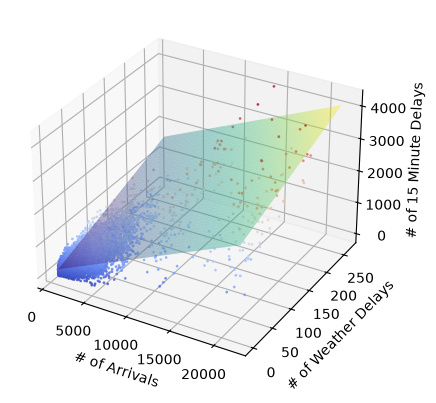

In [48]:
#Matplotlib to visualize

#Defining How Many Dimensions To Use
ax = plt.axes(projection="3d")

#Making The Scatter Plot
ax.scatter(df[['arr_flights']],df[['weather_ct']],df[['arr_del15']], s=1, c=y, cmap = cm.coolwarm)

#Making Mesh Grid To Get Smooth Continuous Plane
Weather_data = np.arange(0, 266.42, 1)
Arrival_data = np.arange(1001, 21977, 1)
X, Y = np.meshgrid(Arrival_data, Weather_data)

#Flattening X and Y to make 1D compatable grid
Q = np.column_stack((X.ravel(), Y.ravel()))

#Retreiving  Z
Z_flat = lr.predict(Q)
Z = Z_flat.reshape(X.shape)

#Creating Plot Surface
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.4, antialiased=True)

#Creating Labels
ax.set_xlabel('# of Arrivals')
ax.set_ylabel('# of Weather Delays')
ax.set_zlabel('# of 15 Minute Delays')

plt.show()


In [49]:
#Prediction Phase
prediction = lr.predict(X_test)
print("Prediction:", prediction)
print("Actual:", y_test)

Prediction: [[220.29519083]
 [247.30918338]
 [318.97730996]
 ...
 [347.02511881]
 [830.52009874]
 [263.07573276]]
Actual:        arr_del15
1722       231.0
8730       116.0
10206      324.0
4367      1048.0
3098       238.0
...          ...
11463      254.0
4246       164.0
5478       378.0
5871       808.0
4601       200.0

[2457 rows x 1 columns]


In [54]:
#Calculating Error
mse = mean_squared_error(y_test, prediction)
rmse = round(math.sqrt(mse))
print("Root Mean Squared Error: ~", rmse)


Root Mean Squared Error: ~ 229


In [55]:
#Error of 229 Flights; Too large, Must have a bigger contributer to 15 minute delays